# Natural Language Processing (NLP) Template
Adapted for dataset https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset


### Step 1: Load Data

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)

# All categories
#all_target_names = fetch_20newsgroups().target_names

# Load dataset here
category_list = [
    'alt.atheism',
    'talk.politics.guns',
    'comp.windows.x',
    'comp.graphics',
    'sci.space',
    'rec.autos',
    'rec.motorcycles', 
]

from sklearn.datasets import fetch_20newsgroups
X, y = fetch_20newsgroups(
    return_X_y=True,
    remove=('headers', 'footers', 'quotes'),
    categories=category_list,
)

# Replace numbers in y with category names

y = [category_list[i] for i in y]
y, X

(['talk.politics.guns',
  'rec.autos',
  'sci.space',
  'rec.motorcycles',
  'rec.autos',
  'sci.space',
  'rec.motorcycles',
  'rec.autos',
  'rec.motorcycles',
  'comp.windows.x',
  'alt.atheism',
  'rec.autos',
  'comp.windows.x',
  'rec.motorcycles',
  'comp.graphics',
  'rec.motorcycles',
  'comp.windows.x',
  'rec.autos',
  'comp.windows.x',
  'comp.graphics',
  'sci.space',
  'talk.politics.guns',
  'rec.motorcycles',
  'alt.atheism',
  'rec.autos',
  'alt.atheism',
  'talk.politics.guns',
  'rec.motorcycles',
  'rec.motorcycles',
  'alt.atheism',
  'rec.motorcycles',
  'rec.autos',
  'sci.space',
  'sci.space',
  'alt.atheism',
  'talk.politics.guns',
  'talk.politics.guns',
  'comp.windows.x',
  'alt.atheism',
  'sci.space',
  'comp.graphics',
  'alt.atheism',
  'comp.graphics',
  'comp.windows.x',
  'comp.graphics',
  'comp.windows.x',
  'talk.politics.guns',
  'sci.space',
  'comp.graphics',
  'alt.atheism',
  'sci.space',
  'talk.politics.guns',
  'alt.atheism',
  'alt.athe

### Step 2: Data Cleanup


In [6]:
import re

def basic_clean(text: str) -> str:
    # Lowercase
    text = text.lower()
    # Remove anything that's not a letter or space
    text = re.sub(r"[^a-z\s]", "", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Cleanup the text data
X = [basic_clean(doc) for doc in X]
X

['okay ive received a whole lot of requests for the movie so for simplicitys sake i cant mail out any more than ive already received as of edt tuesday maybe itll pop up on a site sooner or later',
 'if that were true id go for it i have a few friends who we could pool our resources and do it maybe make it a prize kind of liek the solar car race in australia anybody game for a contest',
 'as a new bmw owner i was thinking about signing up for the moa but right now it is beginning to look suspiciously like throwing money down a rathole when you guys sort this out let me know',
 'if you havent heard yet us senator patty murrey a mom in tennis shoes is planning to introduce legislation to tax all handgun transactions and increase dealer licnese costs in order to raise money to cover the costs of uninsured shooting victums she plans to start with per year dealer fees and or so depending on the type of firearm per gun transaction she plans to make it federal she was elected in washington sta

### Step 3: Create Bag-of-Words


In [7]:
# Vectorize using Bag-of-Words
vectorizer = CountVectorizer(stop_words="english")
X_bow = vectorizer.fit_transform(X)

X_bow.shape  # (n_documents, n_features)
print(f"Number of documents: {X_bow.shape[0]}")
print(f"Number of unique words (features): {X_bow.shape[1]}")
feature_names = vectorizer.get_feature_names_out()
print("Sample feature names:", feature_names[:10])

print(X_bow.toarray()) 

Number of documents: 3988
Number of unique words (features): 39658
Sample feature names: ['aa' 'aaa' 'aaah' 'aaffff' 'aafffff' 'aah' 'aaigcapcorg' 'aamir' 'aan'
 'aangeboden']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [8]:
# See some feature names (or column names)
feature_names = vectorizer.get_feature_names_out()
feature_names[:200]


array(['aa', 'aaa', 'aaah', 'aaffff', 'aafffff', 'aah', 'aaigcapcorg',
       'aamir', 'aan', 'aangeboden', 'aangegeven', 'aantal',
       'aantalsnijpunten', 'aao', 'aap', 'aaplayexe', 'aarm', 'aaron',
       'aarp', 'aarseth', 'aarskog', 'aas', 'aasaiaa', 'aavso', 'ab',
       'abandon', 'abandoned', 'abatement', 'abberation', 'abbie',
       'abbreviation', 'abbreviations', 'abbreviationsacronyms', 'abc',
       'abccpurdueedu', 'abcdef', 'abcdefghijklmnopqrstuvwxyz', 'abd',
       'abducted', 'abekas', 'aben', 'aberdeen', 'abhor', 'abhorred',
       'abhorrent', 'abhout', 'abide', 'abiding', 'abilities', 'ability',
       'abiliy', 'abkect', 'able', 'ablebodied', 'ables', 'ablility',
       'ably', 'abnamro', 'aboard', 'aboce', 'abode', 'aboid', 'abolish',
       'abolished', 'abolishment', 'abomb', 'abombs', 'abomination',
       'abominations', 'abord', 'abort', 'aborted', 'abortion',
       'abortions', 'abound', 'abounds', 'abovementioned', 'abovequoted',
       'abp', 'abpgif'

### Step 4: Create a simple sentiment classifier

Now that we have numeric features from text, we can build a simple classifier to predict sentiment (positive/negative) based on course comments.


Training accuracy: 0.9795772124686493
Test accuracy: 0.7376775271512114


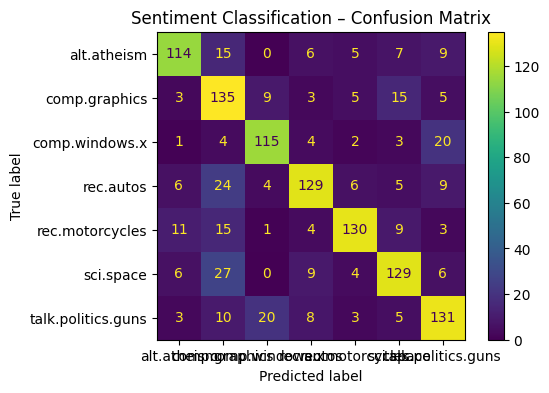

In [9]:

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.3, random_state=42
)

# Train a simple Logistic Regression classifier that uses the Bag-of-Words features (columns)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# How well does it do on the training set?
y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training accuracy: {train_acc}")

# How well does it do on the *test* set?
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc}")

# Confusion Matrix for test set
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("Sentiment Classification – Confusion Matrix")
plt.show()



### Step 5: TF-IDF 


In [10]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(stop_words="english")
X_tfidf = tfidf_vectorizer.fit_transform(X)

X_tfidf.shape
X_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(3988, 39658))

In [11]:
# Compare the Bag-of-Words and TF-IDF features against each other, showing 
# the first 5 rows and first 10 columns of each
print("Bag-of-Words feature matrix (first 5 rows, 10 columns):")
print(X_bow.toarray()[:5, :10])
print("\nTF-IDF feature matrix (first 5 rows, 10 columns):")
print(X_tfidf.toarray()[:5, :10])

Bag-of-Words feature matrix (first 5 rows, 10 columns):
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

TF-IDF feature matrix (first 5 rows, 10 columns):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


Training accuracy: 0.943389466141168
Test accuracy: 0.7702589807852965


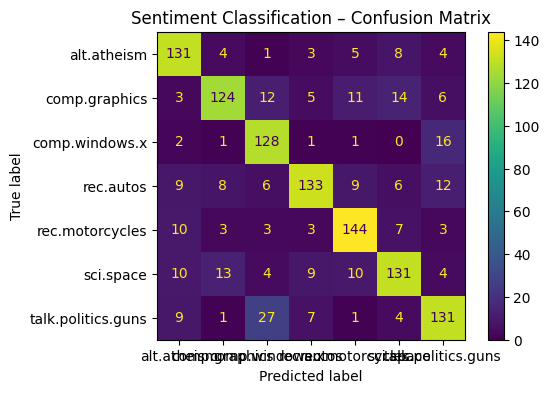

In [12]:
# Do the same train/test split and classification with TF-IDF features
# Use logistical regression again and compare accuracy.
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42
)

clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_t, y_train_t)

# How well does it do on the training set?
y_train_pred = clf_tfidf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training accuracy: {train_acc}")

# How well does it do on the *test* set?
y_pred = clf_tfidf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc}")

# Confusion Matrix for test set
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_tfidf.classes_)
disp.plot()
plt.title("Sentiment Classification – Confusion Matrix")
plt.show()


### Step 6: Clustering to explore topics

In [13]:
k = 5  # we suspect there might be "positive" vs "negative"-like groups
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_tfidf)

df = pd.DataFrame({"text": X, "cluster": clusters, 'newsgroup': y })

df

,text,cluster,newsgroup
0,okay ive received a whole lot of requests for ...,0,talk.politics.guns
1,if that were true id go for it i have a few fr...,3,rec.autos
2,as a new bmw owner i was thinking about signin...,3,sci.space
3,if you havent heard yet us senator patty murre...,0,rec.motorcycles
4,the centaur is controlled technology state dep...,0,rec.autos
...,...,...,...
3983,seems that the milelong billboard and any othe...,4,rec.autos
3984,in regards ot some of the posts concerning bia...,0,sci.space
3985,fred try reading a bit the government does lot...,0,rec.autos
3986,as i understand it the difference between d st...,0,talk.politics.guns


In [14]:
# Get the most common terms for each cluster.
terms = tfidf_vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

cluster_names = []

for cluster_id in range(k):
    print(f"\nCluster {cluster_id}")
    center = centers[cluster_id]
    top_idx = center.argsort()[::-1][:10]
    print([terms[i] for i in top_idx])
    # Save names
    cluster_names.append([terms[i] for i in top_idx])

cluster_names = ["-".join(c) for c in cluster_names]

print(cluster_names)


Cluster 0
['just', 'like', 'know', 'dont', 'think', 'does', 'im', 'use', 'did', 'good']

Cluster 1
['people', 'dont', 'think', 'gun', 'just', 'god', 'say', 'right', 'like', 'know']

Cluster 2
['thanks', 'window', 'program', 'file', 'server', 'know', 'use', 'does', 'files', 'hi']

Cluster 3
['car', 'bike', 'just', 'like', 'engine', 'cars', 'im', 'good', 'new', 'know']

Cluster 4
['space', 'launch', 'nasa', 'moon', 'lunar', 'orbit', 'shuttle', 'data', 'satellite', 'earth']
['just-like-know-dont-think-does-im-use-did-good', 'people-dont-think-gun-just-god-say-right-like-know', 'thanks-window-program-file-server-know-use-does-files-hi', 'car-bike-just-like-engine-cars-im-good-new-know', 'space-launch-nasa-moon-lunar-orbit-shuttle-data-satellite-earth']


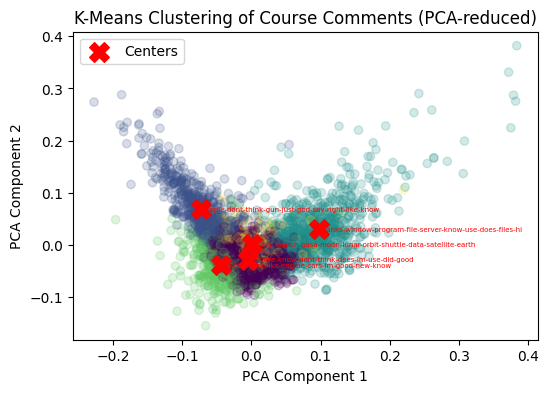

In [15]:
# Visualize clusters using PCA (2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.2)
plt.title("K-Means Clustering of Course Comments (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# show center of each cluster in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Centers')
plt.legend()

# show label for each cluster center using cluster_names
for i, center in enumerate(centers_pca):
    plt.text(center[0], center[1], cluster_names[i], fontsize=5, ha='left', va='center', color='red')

plt.show()

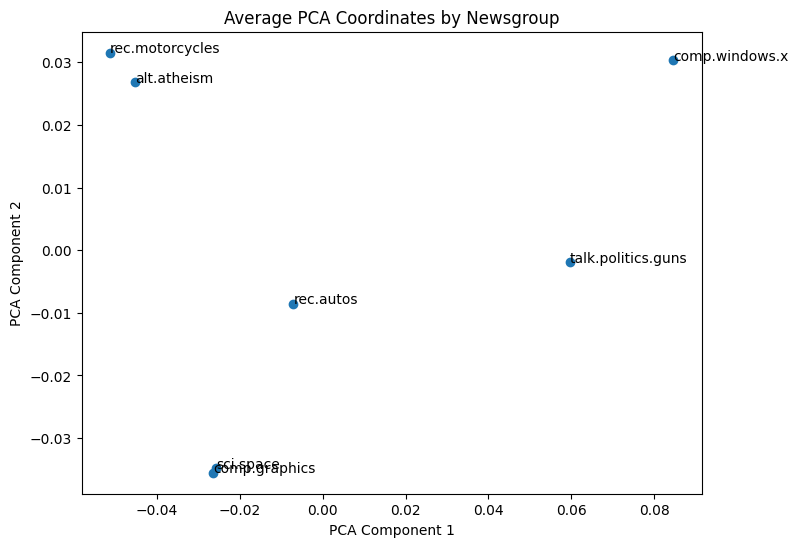

In [16]:
# Add pca components back onto dataframe
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]


# Create the average pca1, pca2 values for each newsgroup.

df.groupby('newsgroup')[['pca1', 'pca2']].mean()

# Plot the average pca1, pca2 for each newsgroup on another scatter plot
import matplotlib.pyplot as plt
avg_coords = df.groupby('newsgroup')[['pca1', 'pca2']].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.scatter(avg_coords['pca1'], avg_coords['pca2'])
for _, row in avg_coords.iterrows():
    plt.text(row['pca1'], row['pca2'], row['newsgroup'])
plt.title("Average PCA Coordinates by Newsgroup")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [17]:
# Identify the most common newsgroup in each cluster
cluster_newsgroup = df.groupby('cluster')['newsgroup'].agg(lambda x: x.value_counts().idxmax())
cluster_newsgroup

cluster
0          sci.space
1    rec.motorcycles
2     comp.windows.x
3      comp.graphics
4          rec.autos
Name: newsgroup, dtype: object